# Notebook 12 – Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Age": [22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 52, 55, 58],
    "Salary": [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000],
    "Department": ["IT", "HR", "IT", "Finance", "HR", "IT", "Finance", "IT", "HR", "Finance", "IT", "HR", "Finance", "IT", "Finance"],
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
}

df = pd.DataFrame(data)

df.head()

,Age,Salary,Department,Experience
0,22,30000,IT,1
1,25,35000,HR,2
2,28,40000,IT,3
3,30,45000,Finance,4
4,32,50000,HR,5


## 1. Important Patterns

### Observation

The data shows that salary generally increases as employee experience increases.

### Insight

Employees with higher experience tend to earn higher salaries. This suggests that experience is an important factor associated with employee compensation.

### Business Impact

The company can use this relationship when planning salary structures, promotions, and employee retention strategies.

In [2]:
experience_salary = df.groupby("Experience")["Salary"].mean()

print(experience_salary)

Experience
1      30000.0
2      35000.0
3      40000.0
4      45000.0
5      50000.0
6      55000.0
7      60000.0
8      65000.0
9      70000.0
10     75000.0
11     80000.0
12     85000.0
13     90000.0
14     95000.0
15    100000.0
Name: Salary, dtype: float64


# 2. Trends

### Observation

The salary values show an increasing pattern as employee experience increases.

### Insight

There is a clear upward trend between experience and salary.

### Business Impact

The company can use this trend when planning salary increases and career progression.

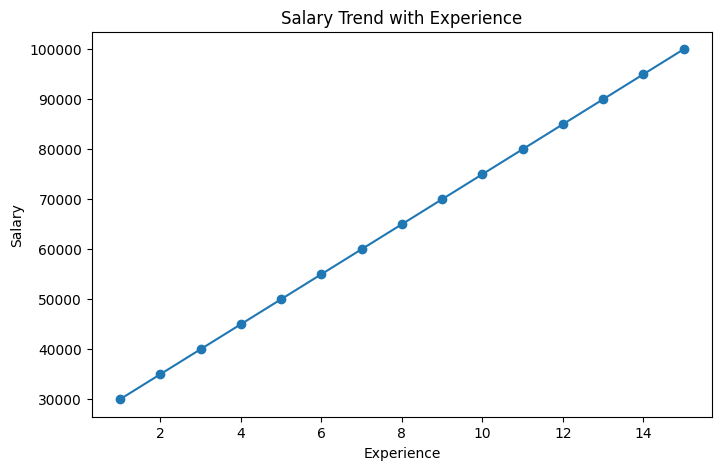

In [3]:
plt.figure(figsize=(8, 5))

plt.plot(df["Experience"], df["Salary"], marker="o")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Salary Trend with Experience")

plt.show()

# 3. Relationships

### Observation

Experience and Salary appear to have a strong positive relationship.

### Insight

Employees with more years of experience generally have higher salaries.

### Business Impact

Experience can be considered an important factor when analyzing employee compensation.

In [4]:
correlation = df["Experience"].corr(df["Salary"])

print("Correlation between Experience and Salary:", correlation)

Correlation between Experience and Salary: 0.9999999999999999


# 4. Anomalies

### Observation

Some salary values may be unusually high or low compared with the rest of the dataset.

### Insight

Unusual salary values could represent senior employees, specialized roles, or possible data-entry errors.

### Business Impact

The company should investigate unusual salary records before using the data for important business decisions.

In [5]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower_limit) |
    (df["Salary"] > upper_limit)
]

print("Potential Salary Outliers:")
print(outliers)

Potential Salary Outliers:
Empty DataFrame
Columns: [Age, Salary, Department, Experience]
Index: []


# 5. Potential Business Problems

### Observation

Average salary and employee experience differ between departments.

### Insight

Some departments may have higher compensation levels because of differences in experience, roles, or required skills.

### Business Problem

Large differences in compensation may require further investigation to determine whether salaries are appropriately aligned with responsibilities and experience.

### Business Impact

The company can review its compensation structure and identify departments that may need attention.

In [6]:
department_analysis = df.groupby("Department").agg(
    Employees=("Department", "count"),
    Average_Salary=("Salary", "mean"),
    Average_Experience=("Experience", "mean")
)

print(department_analysis)

            Employees  Average_Salary  Average_Experience
Department                                               
Finance             5    74000.000000            9.800000
HR                  4    60000.000000            7.000000
IT                  6    60833.333333            7.166667


# 6. Interesting Segments

### Observation

Employees can be grouped according to their departments and compared using salary and experience.

### Insight

Different departments contain employees with different salary and experience levels.

### Business Impact

Department-level analysis can help management understand workforce structure and compensation patterns.

In [7]:
department_salary = df.groupby("Department")["Salary"].mean()

print("Average Salary by Department:")
print(department_salary)

Average Salary by Department:
Department
Finance    74000.000000
HR         60000.000000
IT         60833.333333
Name: Salary, dtype: float64


# 7. Potential Opportunities

### Observation

Salary increases as employee experience increases.

### Insight

The company can use experience and salary patterns to develop clearer career progression paths.

### Business Opportunity

The company could create salary bands based on experience, skills, and job responsibilities.

This may help improve employee motivation and retention.

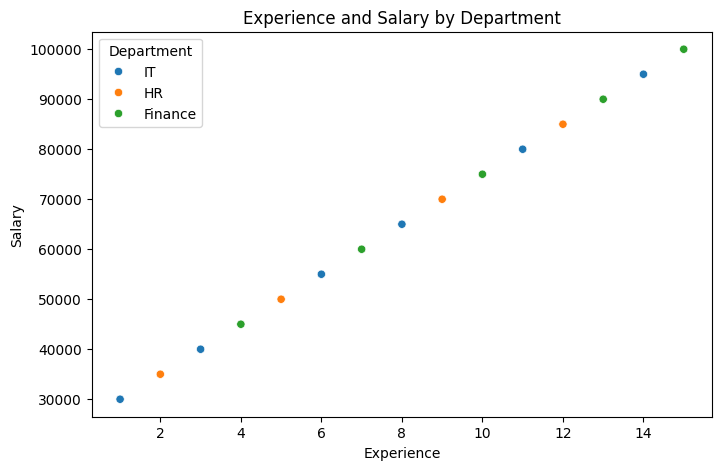

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary",
    hue="Department"
)

plt.title("Experience and Salary by Department")
plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()